# 📈 Linear Regression

**Linear regression** is a statistical technique used to **model and analyze** the relationship between:
- A **dependent variable** (*target*) — the value we want to predict.
- One or more **independent variables** (*features*) — the inputs we believe influence the target.

The goal is to find the **best-fitting straight line** (or **hyperplane** in higher dimensions) ➖ that predicts the target variable based on the input features.

## 🔹 Types of Linear Regression
- **Simple Linear Regression** → Models the relationship between **two variables** using a straight line.  
- **Multiple Linear Regression** → Models the relationship between **one target** and **multiple features**.

## 🎯 Common Use Cases
-  Predicting **house prices**  
- Estimating **sales** based on advertising spend  
- Forecasting **trends** over time  

## ⚙️ How It Works
Linear regression tries to find a line that fits the data points **as closely as possible**, by **minimizing the error** (distance) between the **actual values** and the **predicted values** 📉.

Mathematically, the model can be expressed as:

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_n X_n + \varepsilon
$$

Where:
- **β₀** → Intercept  
- **β₁, β₂, …** → Coefficients (impact of each feature)  
- **ε** → Error term (unexplained variation)


## ⚙️⚙️ How Can we train Our Linear Regression Model? ⚙️⚙️
1. Gather datas and store them into a dataset
2. Do a Study of various values in the dataset to find relationships, outliers ecc.. (eventually we can do features engienniering)
3. Divide into target and features(in other cases we should also divide in training set and evaluation set)
4. Apply standardization to features dataframe
5. Train The model
6. Evaluate results

# Data Preparations :

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('usa_houses.csv')
df = df[(df['price'] < 2700000) & (df['price'] > 10000)] # removing outliers 

# Finding relationships in the datas :

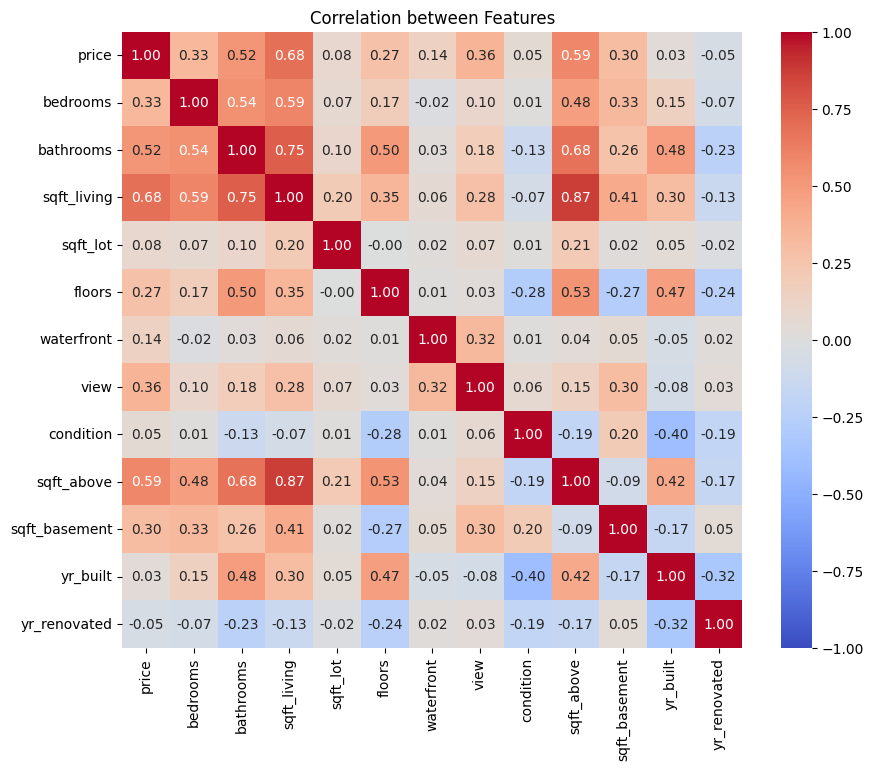

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between Features')
plt.show()

### Dividing in Target dataset and Features dataset and choosing our features

**📂 Training, Validation, and Test Sets**  
In machine learning, we  usuallytypically split our dataset
into three parts to ensure fair training and unbiased evaluation.  

**🏋️ Training Set :** The portion of the data used to **teach** the model.   
The model adjusts its internal parameters based on this data to learn patterns and relationships.

**🧪 Validation Set :**
A separate subset used **during training** to check how well the model generalizes to unseen data.  
It helps in **tuning hyperparameters** and making model selection decisions without touching the test set.

**📝 Test Set :**
A final, untouched portion of the data used **only after training is complete**.  
It provides an **unbiased estimate** of the model’s real-world performance.

In [3]:
features_df = df[['sqft_living', 'bedrooms', 'floors', 'view']]
target_df = df['price']

# Standardization of our Features Dataset

Why we do Standardization/ scaling only on the training/ features set because:  
In machine learning, data leakage happens when information that wouldn’t be available at prediction time accidentally ends up in the training data.  
This gives the model an unfair advantage during training and validation, making it look far more accurate than it will be in the real world.  
If we standardize both sets (training , target) we are influencing the results


In [4]:
from sklearn.preprocessing import RobustScaler

standardized_matrix = RobustScaler().fit_transform(features_df)
standardized_features_df = pd.DataFrame(standardized_matrix, columns=features_df.columns, index=features_df.index)

# Training Linear Regression Model

In [5]:
from sklearn.linear_model import LinearRegression

linear_regression_model = LinearRegression()
linear_regression_model.fit(standardized_features_df, target_df)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Getting our predictions

In [6]:
y_pred = linear_regression_model.predict(features_df)      

# Interpreting our results(linear model Stats)

**📊 Regression Model Evaluation Metrics**:

1. **R² (Coefficient of Determination)** – How much of the variation in the target variable our model explains.
2. **MSE (Mean Squared Error)** – The average squared difference between predictions and actual values.
3. **RMSE (Root Mean Squared Error)** – Like MSE, but in the same units as the target variable.

In [7]:
mse = np.mean((target_df - y_pred)**2)
rmse = np.sqrt(mse)
r2 = linear_regression_model.score(features_df, target_df)
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error (MSE): 405940561468988288.00
Root Mean Squared Error (RMSE): 637134649.40
R² Score: -3789830.7047


# 📉 Linear regression limits

**Linearity**
The model assumes straight‑line relationships between predictors and the target.  
 When the true relationship is curved or involves interactions, systematic errors appear, often visible as patterns in residuals. Consider feature transformations,  
interaction/polynomial terms, or more flexible models.

**Independence of errors**
Residuals should not be correlated across observations. In time or space, clustered errors make uncertainty look smaller than it is,   
undermining p‑values and confidence. Model the dependence (e.g., time‑series methods, clustered/robust errors) when it’s present.  

**Normality of errors**
Approximate normal residuals enable trustworthy confidence intervals and hypothesis tests.  
 Non‑normal, skewed, or heavy‑tailed errors can distort inference even if predictions seem fine.  
  Use transformations, larger samples, robust or bootstrap inference when needed.

**Homoscedasticity**
Error variance should be roughly constant across prediction levels. If variance fans out or shrinks,  
standard errors and risk assessments become unreliable. Diagnose with residual plots and consider target transforms,  
 weighted least squares, or modeling variance.

**Multicollinearity**
Highly correlated predictors make coefficients unstable and hard to interpret, inflating standard errors.  
 Prediction may remain okay, but attribution becomes shaky and signs can flip with small data changes.   
 Reduce redundancy (drop/combine features), regularize, or use dimension reduction.

# Graph of the model :


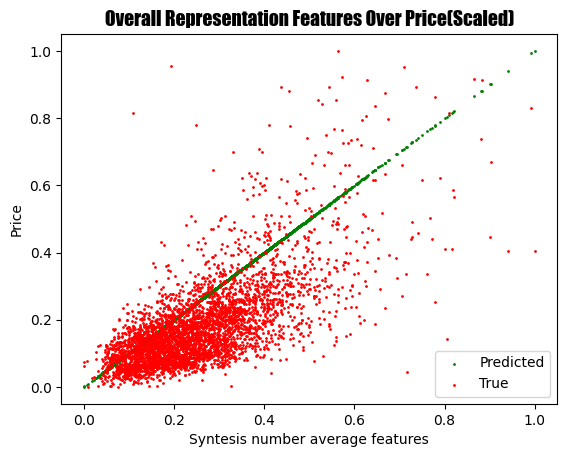

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Creating a new series that capture a relation beween the values
mean_values_df = features_df.mean(axis=1)

# Scaling allows us to fit everything in a single more readable graph
guesses_to_scale_df = pd.DataFrame({"mean_sintetixing": mean_values_df, "predicted_price": y_pred, "true_price" : target_df})
guesses_scaled_matrix = MinMaxScaler().fit_transform(guesses_to_scale_df)

plt.scatter(guesses_scaled_matrix[:, 0], guesses_scaled_matrix[:, 1], s=1, color="green", label="Predicted")
plt.scatter(guesses_scaled_matrix[:, 0], guesses_scaled_matrix[:, 2], color="red", s= 1, label="True")
plt.legend(loc="best")
plt.title("Overall Representation Features Over Price(Scaled)", fontweight="bold", fontsize=14, fontfamily="impact")
plt.xlabel("Syntesis number average features")
plt.ylabel("Price")
plt.show()


# Residual Graph
**Verificating if a problem can be solved with linearity**

What's a residual? : A residual is the difference between the predicted value in this case from the regression and the actual value that had to be predicted

• 	Residuals scattered randomly around zero (no clear pattern)  
• 	Roughly constant spread of residuals across all predicted values (homoscedasticity)  

• 	For lower predicted prices, residuals are tightly clustered → model fits well there.  
• 	For higher predicted prices, residuals spread out more → variance increases with the prediction (heteroscedasticity).  
• 	This “funnel” shape means the model’s errors grow with price — a sign that a simple linear model might not fully capture the relationship.  

Linear Model in this case is kinda good but could be improved(with log that first of lateri will add)

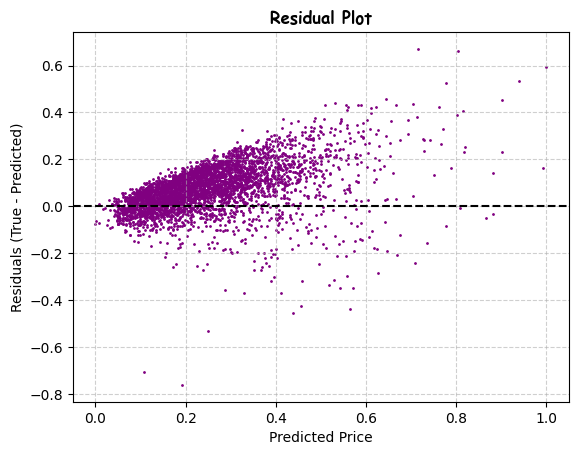

In [9]:
residuals =  guesses_scaled_matrix[:, 1] -  guesses_scaled_matrix[:, 2]

plt.scatter( guesses_scaled_matrix[:, 1], residuals, s=1, color="purple")
plt.axhline(y=0, color='black', linestyle='--')  # reference line at zero
plt.title("Residual Plot", fontweight="bold", fontname="Comic Sans MS")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (True - Predicted)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Diangniostic of the model

### Anova Table (ANALISIS OF VARIANCE):

An ANOVA table explains where the variation in your data comes from and whether the factor(s)  
you’re testing have a statistically significant effect on the outcome.  
ANOVA explains whether the differences you see between groups or variables are real or just random noise.
ANOVA is like a referee that looks at your data and says, “Yes, this variable really matters” or “No, the difference you see is probably just luck.”(chatgpt)


# Wich Models is used on:
- 	Logistic Regression
- 	Support Vector Machines
- 	Decision Trees / Random Forests (as a preprocessing step)
- 	k-Nearest Neighbors

# ANOVA Table Explanations
- sum_sq (Sum of Squares) → How much variation in the target variable (price) is explained by that factor. Bigger = more explanatory power.
- df (Degrees of Freedom) → How many independent pieces of information were used to estimate that variation.
- F → The F-statistic: a ratio of explained variance to unexplained variance. Higher = stronger evidence the factor matters.
- PR(>F) → The p-value: probability that the observed effect is due to chance. Very small values (close to 0) mean the effect is statistically significant.
- Residuals row does the analisis 

In [10]:
import statsmodels.formula.api as smf # using a formula syntax similar to R (e.g., "y ~ x1 + x2").
from statsmodels.stats.anova import anova_lm # Import the ANOVA function to perform Analysis of Variance on a fitted model.

# Fit an Ordinary Least Squares (OLS) regression model:
# "price" is the dependent variable (target),
# "sqft_living" and "view" are independent variables (predictors).
# 'data=df' tells statsmodels to look for these columns in the DataFrame df.
model_formula = smf.ols("price ~ sqft_living + view", data=df).fit()

# Perform ANOVA (Analysis of Variance) on the fitted model.
# typ=2 specifies Type II ANOVA, which is common when predictors are not orthogonal.
# It tests each variable's effect after accounting for the other variables in the model.
anova_table = anova_lm(model_formula, typ=2)

print(anova_table)
# - sum_sq: variation explained by each predictor
# - df: degrees of freedom
# - F: F-statistic (signal-to-noise ratio)
# - PR(>F): p-value (significance of the predictor)

                   sum_sq      df            F        PR(>F)
sqft_living  1.601046e+14     1.0  2948.611970  0.000000e+00
view         1.293051e+13     1.0   238.138327  2.936707e-52
Residual     2.212113e+14  4074.0          NaN           NaN


## 📊 VIF — Variance Inflation Factor

**Variance Inflation Factor (VIF)** is a diagnostic metric used to detect **multicollinearity** in regression models — when one feature is too similar to others.

### 🔍 Why It Matters

- When predictors are highly correlated, the model struggles to isolate their individual effects.
- This leads to **unstable coefficients**, inflated standard errors, and unreliable interpretations.
- VIF helps identify which features may be redundant or problematic.


### 📈 Interpretation Guide

| VIF Value | Meaning                              | Action                        |
|-----------|--------------------------------------|-------------------------------|
| ≈ 1       | No correlation with other features   | ✅ Safe to keep               |
| 1–5       | Moderate correlation                 | ⚠️ Usually acceptable         |
| 5–10      | High correlation                     | ❌ Investigate further        |
| > 10      | Very high multicollinearity          | 🚨 Consider removing or combining features |

In [11]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor #calculates the VIF for a given feature, which measures how much multicollinearity it has with the other features.

def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns     # Add a column with the  names of the columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))    ]
    return vif_data

print("VIF for the features:", calculate_vif(df[["price","sqft_living","view"]]))

VIF for the features:        feature       VIF
0        price  7.344543
1  sqft_living  6.990445
2         view  1.226587


# Residual Distribution and Normality Check for Regression Models


1️⃣ What a Q‑Q plot is checking  
• 	Purpose: Compare the distribution of your residuals to a perfect normal distribution.  
• 	How to read it:  
• 	X‑axis: Theoretical quantiles from a normal distribution.  
• 	Y‑axis: Quantiles from your actual residuals.  
• 	Red line: Where the points would fall if your residuals were perfectly normal.  
• 	Blue dots: Your actual residuals.  

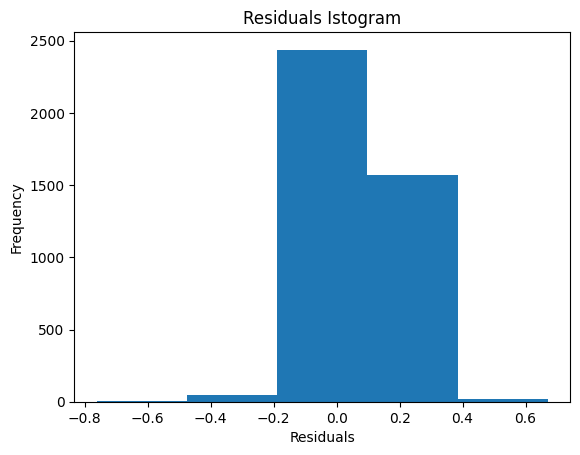

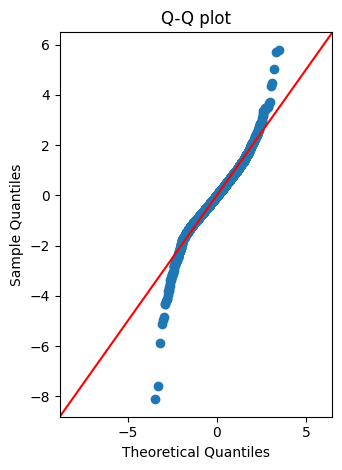

In [12]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Istogramm of residuals
plt.hist(residuals, bins=5) # The histogram gives you a general feel for the shape of the residuals.
"""
Histogram of residuals to visualize error distribution
Residuals: array of model errors (True - Predicted)
Bins=5: divides the residuals into 5 intervals (bars) to show frequency
"""
plt.title("Residuals Istogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

 # Q-Q plot
plt.subplot(1, 2, 2)

""" PARAMETER EXPLANATION
residuals: array of model errors (True - Predicted)
line="45": adds a 45° reference line representing perfect normality
fit=True: scales the sample data to match the theoretical distribution
"""
sm.qqplot(residuals, line="45", fit=True, ax=plt.gca()) # The Q-Q plot gives you a precise diagnostic for normality — especially useful for statistical tests and confidence intervals
plt.title("Q-Q plot")
plt.tight_layout()
plt.show()

# ---How interpret Graphs---------

### Q-Q Plot 🎯 (Quantile–Quantile Plot)
- If residuals are normally distributed, the blue dots will fall close to the red 45° line.
- If they curve away from the line, especially at the ends (tails), it means:
    - You might have skewness (asymmetry)
    - Heavy/light tails (more or fewer extreme values than expected)


### Hist Plot Explanations 🎯 
- If the histogram is symmetric and centered around zero, it means model’s errors are balanced — it’s not consistently over- or under-predicting.
- If it’s skewed, has multiple peaks, or shows outliers, it could mean:
    - Your model is missing important features
    - The relationship isn’t purely linear
    - You might need to transform the target or predictors